# IS 4487 Lab 11

## Learning Objective

Use Linear Regression to predict the AQI in Utah.

## Outline

- Pull the latest "Daily AQI by County" file from this link: https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI

- Your target variable will be *AQI", which is the value of the air quality index

- We will focus the analysis on only the air quality in the state of Utah.  

- Note that there is a several-month lag in preparing data; you should check to see if your file has a full year of data from January to December.  If not, use the previous year.    

- The AQI is divided into six categories:

*Air Quality Index*

|(AQI) Values	|Levels of Health Concern	        |
|---------------|--------|
|0-50	        |Good	 |
|51-100	        |Moderate	 |
|101-150	    |Unhealthy for Sensitive Groups	|
|151 to 200	    |Unhealthy	 |
|201 to 300	    |Very Unhealthy	 |
|301 to 500	    |Hazardous	 |

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_11_air_quality_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Import Data into Dataframe

➡️ Assignment Tasks
- Pull the latest full year of data using the "Daily AQI by County" files from this link: https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
- Make sure to UNZIP the file
- Import data from the air quality dataset into a dataframe
- Describe or profile the dataframe

In [3]:
df = pd.read_csv('https://github.com/MHN-Main/4487/blob/main/daily_aqi_by_county_2024.csv?raw=true')
df.describe()

,State Code,County Code,AQI,Number of Sites Reporting
count,206919.000000,206919.000000,206919.000000,206919.000000
mean,30.068205,80.430077,42.051513,1.898095
std,15.845597,92.711027,19.166162,2.279127
min,1.000000,1.000000,0.000000,1.000000
25%,17.000000,23.000000,32.000000,1.000000
50%,30.000000,59.000000,41.000000,1.000000
75%,42.000000,107.000000,50.000000,2.000000
max,80.000000,810.000000,1322.000000,33.000000


## Prepare Data

➡️ Assignment Tasks
- Filter the data to use Utah data only
- Create one dummy variable (true/false) for each of the Defining Parameter values    
- Create variables for month of year, year, and season
- Perform any other data cleanup needed (remove outliers, nulls, etc.)
- After filtering for Utah, remove the geographical variables that remain (county, state) since those non-numeric values can't be used.  Remove any other non-numeric variables.
- Select the data you would like to use in the model.  If you aggregate data, you will have to decide whether to use the min, max or mean value for AQI
- Split the data 80/20 for training and testing

In [4]:
#filter for Utah data only
df_utah = df[df['State Name'] == 'Utah']

In [5]:
#create columns
#dummy vars
defining_parameters = pd.get_dummies(df_utah['Defining Parameter'], prefix='Defining_Parameter', dtype=int)
df_utah = pd.concat([df_utah, defining_parameters], axis=1)
#month year season
df_utah['Date'] = pd.to_datetime(df_utah['Date'])
df_utah['Month'] = df_utah['Date'].dt.month
df_utah['Year'] = df_utah['Date'].dt.year

# Function to assign seasons based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
df_utah['Season'] = df_utah['Month'].apply(get_season)



In [6]:
#data cleanup
df_utah.dropna(inplace=True)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_no_outliers

# Apply to AQI column
df_utah = remove_outliers_iqr(df_utah, 'AQI')

# Remove geographical columns
df_utah = df_utah.drop(['county Name', 'State Name'], axis=1)

# Remove other non-numeric columns
df_utah = df_utah.select_dtypes(include=np.number)

In [7]:
#select final columns for use
features = ['Month', 'Year', 'Defining_Parameter_CO', 'Defining_Parameter_NO2',
            'Defining_Parameter_Ozone', 'Defining_Parameter_PM10',
            'Defining_Parameter_PM2.5']
target = 'AQI'

X = df_utah[features]
y = df_utah[target]

In [8]:
#split the data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Create Model

➡️ Assignment Tasks
- Create a simple linear regression to predict AQI based on as many variables as you can use or derive.  (for example, sklearn LinearRegression)
- Evaluate the model by displaying the R squared value  
- Visualize the correlation between the target variable and at least one of the independent variables

In [9]:
#create regression or classification model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [10]:
#print the R squared value
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print('R-squared:', r2)

R-squared: 0.045603043425819


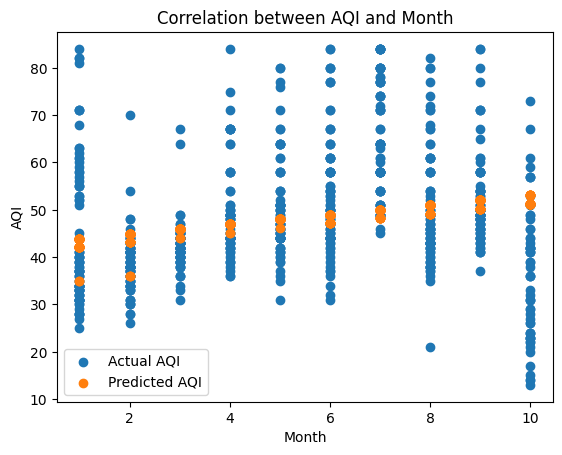

In [11]:
#visual
plt.scatter(X_test['Month'], y_test, label="Actual AQI")
plt.scatter(X_test['Month'], y_pred, label="Predicted AQI")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.title("Correlation between AQI and Month")
plt.legend()
plt.show()

## Make a prediction

➡️ Assignment Tasks
- What would you predict the average AQI to be in January of the upcoming year?  

In [31]:
#predicted AQI
january_data = {
    'Month': [1],
    'Year': [2025],
    'Defining_Parameter_CO': [0],
    'Defining_Parameter_NO2': [0],
    'Defining_Parameter_Ozone': [0],
    'Defining_Parameter_PM10': [0],
    'Defining_Parameter_PM2.5': [1]
    }
january_df = pd.DataFrame(january_data)
predicted_aqi = model.predict(january_df)
print(f"Predicted average AQI for Jan 2025 is: {predicted_aqi}")

Predicted average AQI for Jan 2025 is: [42.11942636]


## OPTIONAL: Compare Air Quality

➡️ Assignment Tasks
- Download the data from several previous years using this website: https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
- Append the new data to the previous dataframe
- Use the year as a variable in your regression.  Is year a significant factor in predicting AQI?

In [ ]:
#import, append and create new model